In [9]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Construcción y evaluación del modelo predictivo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv('../data/datos_alumnos.csv')

# Definir las características (Features o 'X')
X = df[['promedio_general', 'porcentaje_asistencia', 'tareas_entregadas']]

# Definir el objetivo (Target o 'y') 
# 1 = En Riesgo Alto (Deserción/Reprobación), 0 = Sin Riesgo
y = df['riesgo_academico']

In [11]:
# Separar los datos (80% para entrenar, 20% para examen)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar el modelo predictivo
sara_model = LogisticRegression()

# ¡Aquí ocurre la magia! Entrenar el modelo con los datos
sara_model.fit(X_train, y_train)

print("¡Modelo SARA entrenado con éxito!")

¡Modelo SARA entrenado con éxito!


In [12]:
# Pedirle a SARA que prediga el riesgo de los alumnos de prueba (el 20% oculto)
predicciones = sara_model.predict(X_test)
probabilidades = sara_model.predict_proba(X_test)

# Ver qué tan preciso fue el modelo
precision = accuracy_score(y_test, predicciones)
print(f"Precisión del modelo: {precision * 100}%")

Precisión del modelo: 92.0%


--- MÉTRICAS DEL MODELO SARA ---
               precision    recall  f1-score   support

   Normal (0)       0.93      0.96      0.94        71
En Riesgo (1)       0.89      0.83      0.86        29

     accuracy                           0.92       100
    macro avg       0.91      0.89      0.90       100
 weighted avg       0.92      0.92      0.92       100



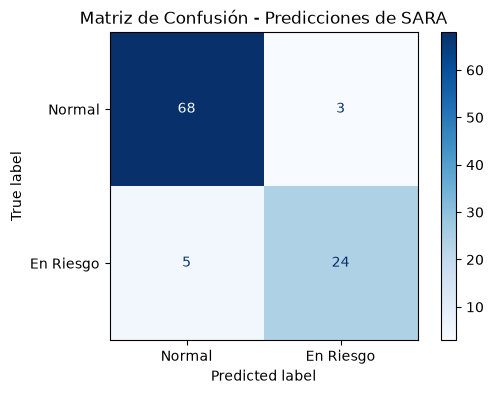

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Generar el Reporte de Métricas Completo
print("--- MÉTRICAS DEL MODELO SARA ---")
print(classification_report(y_test, predicciones, target_names=['Normal (0)', 'En Riesgo (1)']))

# 2. Generar y dibujar la Matriz de Confusión
cm = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'En Riesgo'])

# Configurar colores (usamos azul para mantener la estética profesional)
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Predicciones de SARA')
plt.show()